In [67]:
import pandas as pd
import numpy as np

# Make numpy values easier to read.
np.set_printoptions(precision=3, suppress=True)

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [60]:
header = np.concatenate(
    (["Input %s" % i for i in range(8)], ["Output %s" % i for i in range(6)])
)
data = pd.read_csv('XFEL_KW0_Results_2.csv', names=header)
data = data.drop(["Input 6", "Output 0", "Output 4"], axis=1)

In [61]:
normalized_data = (data-data.min())/(data.max()-data.min())

train, test = train_test_split(normalized_data, test_size=0.2)

xtrain, ytrain = train[np.concatenate((["Input %s" % i for i in range(6)],["Input 7"]))], train[np.concatenate((["Output %s" % i for i in range(1,4)],["Output 5"]))]
xtest, ytest = test[np.concatenate((["Input %s" % i for i in range(6)],["Input 7"]))], test[np.concatenate((["Output %s" % i for i in range(1,4)],["Output 5"]))]

In [69]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=7),
    layers.Dense(16, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(4),
])

model.compile(
    #optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['accuracy']
)

history = model.fit(
    xtrain, ytrain,
    batch_size=128,
    epochs=7,
    validation_data = (xtest, ytest),
)

Epoch 1/7
7068/7068 [==============================] - 38s 5ms/step - loss: 0.0224 - accuracy: 0.8020 - val_loss: 2.2325e-04 - val_accuracy: 0.9640
Epoch 2/7
7068/7068 [==============================] - 30s 4ms/step - loss: 2.0478e-04 - accuracy: 0.9662 - val_loss: 1.9700e-04 - val_accuracy: 0.9675
Epoch 3/7
7068/7068 [==============================] - 31s 4ms/step - loss: 1.9776e-04 - accuracy: 0.9664 - val_loss: 1.9246e-04 - val_accuracy: 0.9677
Epoch 4/7
7068/7068 [==============================] - 31s 4ms/step - loss: 1.9746e-04 - accuracy: 0.9665 - val_loss: 2.0549e-04 - val_accuracy: 0.9671
Epoch 5/7
7068/7068 [==============================] - 31s 4ms/step - loss: 1.9724e-04 - accuracy: 0.9667 - val_loss: 2.1227e-04 - val_accuracy: 0.9606
Epoch 6/7
7068/7068 [==============================] - 34s 5ms/step - loss: 1.9682e-04 - accuracy: 0.9666 - val_loss: 1.9772e-04 - val_accuracy: 0.9670
Epoch 7/7
7068/7068 [==============================] - 31s 4ms/step - loss: 1.9640e-04 - acc

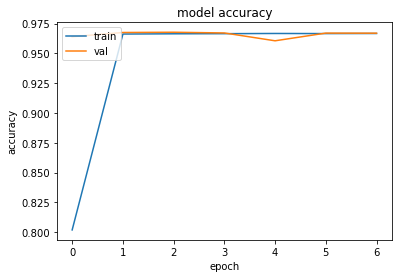

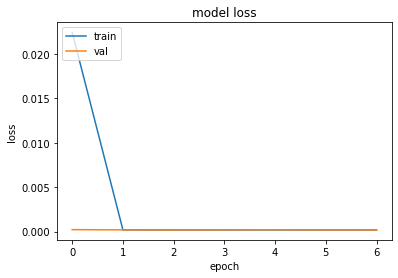

In [70]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [71]:
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(xtest, ytest, batch_size=128)
print("test loss, test acc:", results)

# Generate predictions (probabilities -- the output of the last layer)
# on new data using `predict`
print("Generate predictions for 3 samples")
predictions = model.predict(xtest[:3])
print("example predictions:\n", predictions)

Evaluate on test data
1767/1767 [==============================] - 6s 3ms/step - loss: 1.9317e-04 - accuracy: 0.9669
test loss, test acc: [0.00019316574616823345, 0.9669445157051086]
Generate predictions for 3 samples
1/1 [==============================] - 0s 136ms/step
example predictions:
 [[0.47  0.416 0.172 0.461]
 [0.603 0.603 0.206 0.786]
 [0.663 0.419 0.158 0.566]]
